In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import sys
sys.path.append("../utils")
from indicators import compute_rsi

print("Ready")

Ready


In [2]:
df = yf.download("SPY", start="2010-01-01",
                  end="2024-01-01", auto_adjust=True)
df.columns = df.columns.get_level_values(0)

high  = df["High"].squeeze()
low   = df["Low"].squeeze()
close = df["Close"].squeeze()
log_returns = np.log(close / close.shift(1)).dropna()

print(f"Loaded {len(close)} trading days")
print(f"Columns available: {df.columns.tolist()}")

[*********************100%***********************]  1 of 1 completed

Loaded 3522 trading days
Columns available: ['Close', 'High', 'Low', 'Open', 'Volume']


In [3]:
def compute_atr(high, low, close, period=14):
    """
    Average True Range — volatility measure that
    accounts for gaps between sessions.
    """
    prev_close = close.shift(1)
    tr1 = high - low
    tr2 = (high - prev_close).abs()
    tr3 = (low  - prev_close).abs()
    true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = true_range.rolling(period).mean()
    return atr

atr = compute_atr(high, low, close)

print(f"ATR stats:")
print(f"  Current ATR : ${atr.iloc[-1]:.2f}")
print(f"  Current price: ${close.iloc[-1]:.2f}")
print(f"  ATR as % of price: {(atr.iloc[-1]/close.iloc[-1]):.2%}")
print(f"  Mean ATR    : ${atr.mean():.2f}")
print(f"  ATR during COVID (2020-03-23): ${atr.loc['2020-03-23']:.2f}")

ATR stats:
  Current ATR : $3.71
  Current price: $462.58
  ATR as % of price: 0.80%
  Mean ATR    : $2.88
  ATR during COVID (2020-03-23): $17.17


In [4]:
# Rebuild RSI(2) + trend filter signals
sma200 = close.rolling(200).mean()
rsi2   = compute_rsi(close, period=2)

# Generate entry/exit points as a list of trades
trades = []
in_trade = False
entry_idx = None

for i in range(200, len(close)):
    in_uptrend = close.iloc[i] > sma200.iloc[i]

    if not in_trade:
        if rsi2.iloc[i] < 10 and in_uptrend:
            in_trade = True
            entry_idx = i
    else:
        if rsi2.iloc[i] > 90 or not in_uptrend:
            # Exit trade
            exit_idx = i
            entry_price = close.iloc[entry_idx]
            exit_price  = close.iloc[exit_idx]
            ret = (exit_price / entry_price) - 1

            # Calculate MAE — lowest point during the trade
            trade_prices = close.iloc[entry_idx:exit_idx+1]
            mae = (trade_prices.min() / entry_price) - 1

            trades.append({
                "entry_date": close.index[entry_idx],
                "exit_date" : close.index[exit_idx],
                "entry_price": entry_price,
                "exit_price" : exit_price,
                "return": ret,
                "mae": mae,
                "duration": exit_idx - entry_idx,
                "atr_at_entry": atr.iloc[entry_idx]
            })
            in_trade = False

trades_df = pd.DataFrame(trades)
print(f"Total trades        : {len(trades_df)}")
print(f"Win rate            : {(trades_df['return']>0).mean():.1%}")
print(f"Avg win             : {trades_df[trades_df['return']>0]['return'].mean():.2%}")
print(f"Avg loss            : {trades_df[trades_df['return']<0]['return'].mean():.2%}")
print(f"Avg trade duration  : {trades_df['duration'].mean():.1f} days")
print(f"Avg MAE             : {trades_df['mae'].mean():.2%}")
print(f"Worst MAE           : {trades_df['mae'].min():.2%}")

Total trades        : 84
Win rate            : 76.2%
Avg win             : 1.94%
Avg loss            : -2.58%
Avg trade duration  : 10.7 days
Avg MAE             : -1.73%
Worst MAE           : -7.73%


Expectancy per trade: 0.860%
Over 84 trades, total: 72.28%


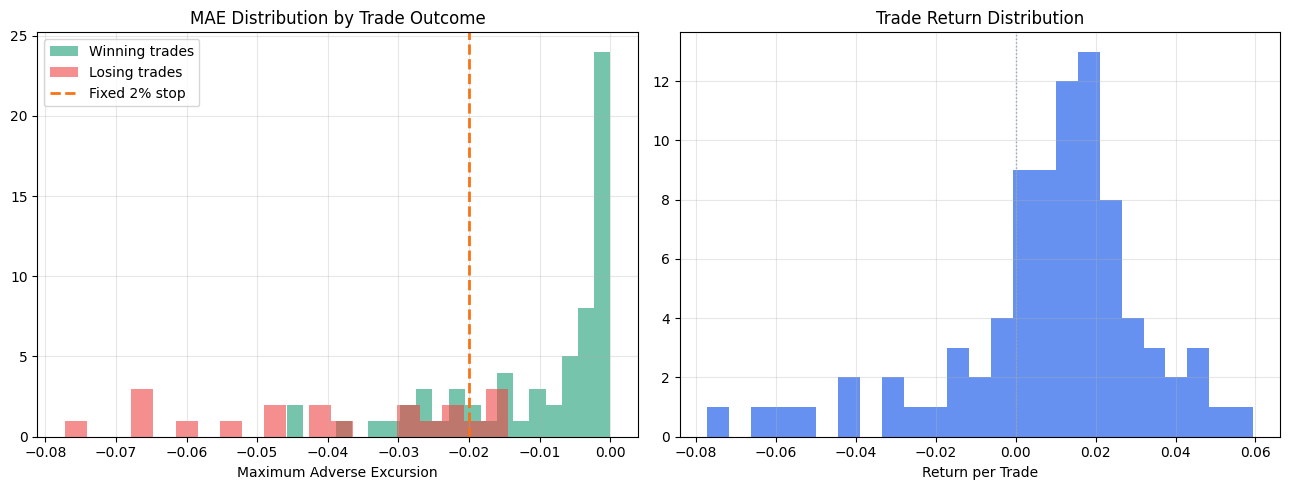


Winning trades that would hit -2% stop: 14 of 64


In [5]:
# Expectancy calculation
win_rate  = (trades_df['return']>0).mean()
avg_win   = trades_df[trades_df['return']>0]['return'].mean()
avg_loss  = trades_df[trades_df['return']<0]['return'].mean()
expectancy = (win_rate * avg_win) + ((1-win_rate) * avg_loss)

print(f"Expectancy per trade: {expectancy:.3%}")
print(f"Over 84 trades, total: {expectancy*84:.2%}")

# Plot MAE distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# MAE for winning vs losing trades
winners = trades_df[trades_df['return']>0]['mae']
losers  = trades_df[trades_df['return']<0]['mae']

ax1.hist(winners, bins=20, alpha=0.6, color='#1D9E75', label='Winning trades')
ax1.hist(losers,  bins=20, alpha=0.6, color='#ef4444', label='Losing trades')
ax1.axvline(-0.02, color='#f97316', lw=2, linestyle='--', label='Fixed 2% stop')
ax1.set_title('MAE Distribution by Trade Outcome')
ax1.set_xlabel('Maximum Adverse Excursion')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Returns distribution
ax2.hist(trades_df['return'], bins=25, color='#2563eb', alpha=0.7)
ax2.axvline(0, color='#94a3b8', lw=1, linestyle=':')
ax2.set_title('Trade Return Distribution')
ax2.set_xlabel('Return per Trade')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# How many winners would have been stopped out at 2%?
winners_stopped = (winners < -0.02).sum()
print(f"\nWinning trades that would hit -2% stop: {winners_stopped} of {len(winners)}")

In [6]:
# Simulate three scenarios: no stop, 2% fixed stop, 2xATR stop
def simulate_with_stop(trades_df, stop_type="none", stop_value=0.02):
    """
    Recalculate trade returns assuming a stop loss.
    stop_type: 'none', 'fixed', 'atr'
    """
    new_returns = []
    for _, trade in trades_df.iterrows():
        if stop_type == "none":
            new_returns.append(trade['return'])
        elif stop_type == "fixed":
            if trade['mae'] < -stop_value:
                new_returns.append(-stop_value)  # stopped out
            else:
                new_returns.append(trade['return'])
        elif stop_type == "atr":
            atr_pct = trade['atr_at_entry'] / trade['entry_price']
            stop_threshold = -stop_value * atr_pct
            if trade['mae'] < stop_threshold:
                new_returns.append(stop_threshold)
            else:
                new_returns.append(trade['return'])
    return pd.Series(new_returns)

# Run all three scenarios
no_stop   = simulate_with_stop(trades_df, "none")
fixed_2pc = simulate_with_stop(trades_df, "fixed", 0.02)
atr_2x    = simulate_with_stop(trades_df, "atr", 2.0)

def trade_stats(returns, name):
    wr  = (returns > 0).mean()
    aw  = returns[returns>0].mean() if (returns>0).any() else 0
    al  = returns[returns<0].mean() if (returns<0).any() else 0
    exp = (wr*aw) + ((1-wr)*al)
    total = returns.sum()
    print(f"  {name:<20} WR:{wr:>6.1%}  AvgWin:{aw:>7.2%}  AvgLoss:{al:>7.2%}  Exp:{exp:>7.3%}  Total:{total:>7.2%}")

print(f"\n{'='*75}")
print(f"  STOP COMPARISON — 84 RSI(2) trades")
print(f"{'='*75}")
trade_stats(no_stop,   "No Stop")
trade_stats(fixed_2pc, "Fixed 2% Stop")
trade_stats(atr_2x,    "2x ATR Stop")
print(f"{'='*75}")


  STOP COMPARISON — 84 RSI(2) trades
  No Stop              WR: 76.2%  AvgWin:  1.94%  AvgLoss: -2.58%  Exp: 0.860%  Total: 72.28%
  Fixed 2% Stop        WR: 59.5%  AvgWin:  2.20%  AvgLoss: -1.91%  Exp: 0.539%  Total: 45.25%
  2x ATR Stop          WR: 58.3%  AvgWin:  2.27%  AvgLoss: -1.89%  Exp: 0.540%  Total: 45.39%


In [7]:
import inspect

code = """import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

""" + inspect.getsource(compute_atr) + "\n\n" + inspect.getsource(simulate_with_stop)

with open("../utils/trade_management.py", "w",
          encoding="utf-8") as f:
    f.write(code)

print("Saved to utils/trade_management.py")

Saved to utils/trade_management.py
